https://github.com/robert-koch-institut/SARS-CoV-2-Infektionen_in_Deutschland

#### Filter nur die Zeilen raus, die für die "Gemeinde" 8111 = Stuttgart gespeichert wurden

In [5]:
# with open("Aktuell_Deutschland_SarsCov2_Infektionen.txt", "r") as f:
#     lines = [line for line in f if line.startswith("8111,")]

# with open("gefiltertauf8111.csv", "w") as f:
#     f.writelines(lines)

#### Wieviele davon haben kein eindeutiges Erkrankungsdatum?

In [6]:
with open("gefiltertauf8111.csv", "r") as f:
    lines = f.readlines()

gesamt = len(lines)
ohneerkrankungsdatum = sum(1 for line in lines if line.strip().split(",")[5] == "0")

print("Gesamt:", gesamt)
print("Mit Spalte 6 = 0:", ohneerkrankungsdatum, ", d.h.", f"{(ohneerkrankungsdatum/gesamt)*100:.2f} % mit unklarem Erkrankungsbeginn")


Gesamt: 28868
Mit Spalte 6 = 0: 11363 , d.h. 39.36 % mit unklarem Erkrankungsbeginn


#### Auswertung mit allen Daten

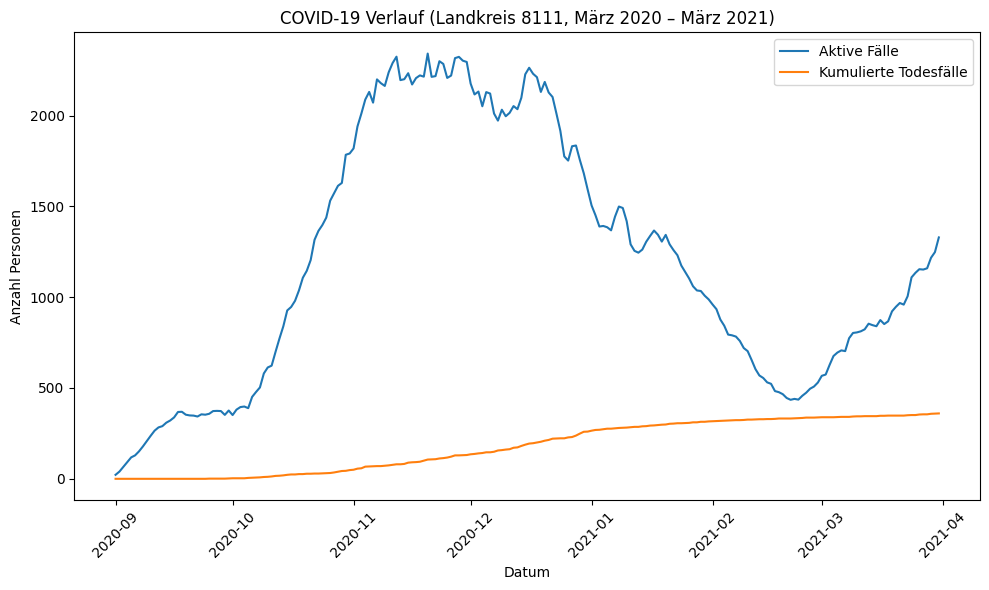

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV einlesen
df = pd.read_csv("gefiltertauf8111.csv", header=None)
df.columns = [
    "IdLandkreis", "Altersgruppe", "Geschlecht", "Meldedatum", "Refdatum",
    "IstErkrankungsbeginn", "NeuerFall", "NeuerTodesfall", "NeuGenesen",
    "AnzahlFall", "AnzahlTodesfall", "AnzahlGenesen"
]

# Nur gültige Daten (keine Korrekturen)
df = df[
    (df["NeuerFall"] != -1) &
    (df["NeuerTodesfall"] != -1) &
    (df["NeuGenesen"] != -1)
]

# Datum formatieren
df["Meldedatum"] = pd.to_datetime(df["Meldedatum"])

# Nach Datum gruppieren
daily = df.groupby("Meldedatum")[["AnzahlFall", "AnzahlTodesfall", "AnzahlGenesen"]].sum().sort_index()

# Zeitraum filtern: März 2020 bis März 2021
daily = daily[(daily.index >= "2020-09-01") & (daily.index <= "2021-03-31")]

# Genesene 14 Tage versetzt
daily["AnzahlGenesen_versetzt"] = daily["AnzahlGenesen"].shift(14).fillna(0)

# Kumulative Werte
daily["AktiveFaelle"] = daily["AnzahlFall"].cumsum() - daily["AnzahlGenesen_versetzt"].cumsum() - daily["AnzahlTodesfall"].cumsum()
daily["KumuliertTodesfall"] = daily["AnzahlTodesfall"].cumsum()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(daily.index, daily["AktiveFaelle"], label="Aktive Fälle")
plt.plot(daily.index, daily["KumuliertTodesfall"], label="Kumulierte Todesfälle")
# plt.plot(daily.index, daily["AnzahlGenesen_versetzt"].cumsum(), label="Kumulierte Genesene (versetzt)")
plt.xlabel("Datum")
plt.ylabel("Anzahl Personen")
plt.title("COVID-19 Verlauf (Landkreis 8111, März 2020 – März 2021)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

